In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('star_classification.csv')
#Verifying whether dataset has loaded properly
print("Dataset Shape : ", df.shape)
print("\nFirat five rows : ")
print(df.head())

print("\nDataset info : ")
df.info()

Dataset Shape :  (100000, 18)

Firat five rows : 
         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.6

In [6]:
#to check class balance
print("Class Distribution:")
print(df['class'].value_counts())

#to sweparate features(X), target(y)
#to drop metadata IDs that have no physical meaning wrt stellar physics(here assigned no's for a few parameters have been chiosen)
columns_to_drop = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
X = df.drop(columns=columns_to_drop + ['class'])
y = df['class']

print("\nThe remaining physical features that will be used for training are : ")
print(X.columns.tolist())

Class Distribution:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

The remaining physical features that will be used for training are : 
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


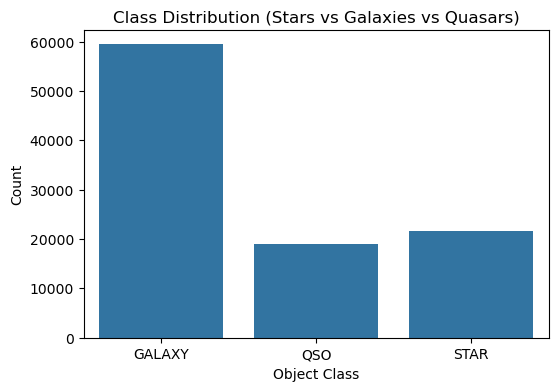

Data successfully split!
Training set shape: (80000, 8)
Testing set shape: (20000, 8)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# to visualize class balance (Requirement: Exploratory Analysis)
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution (Stars vs Galaxies vs Quasars)')
plt.xlabel('Object Class')
plt.ylabel('Count')
plt.show()

#to encode target labels ('GALAXY', 'STAR', 'QSO') into numbers (0, 1, 2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

#Train-Test Split (80% of the data for training, 20% of it for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(u"Data successfully split!")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

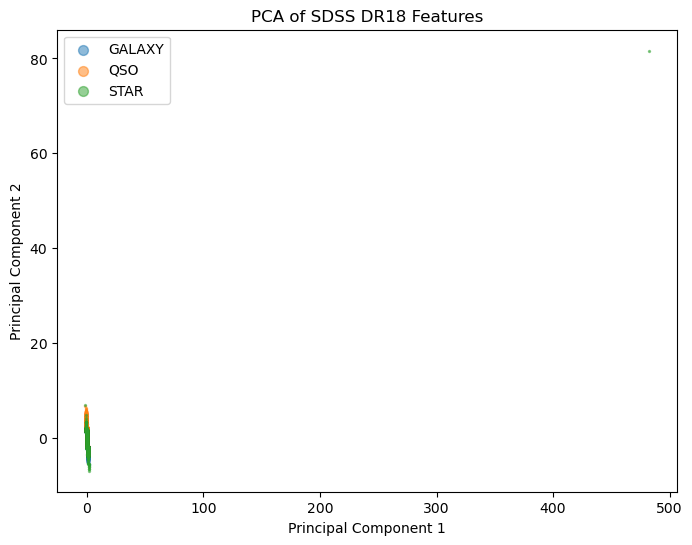


Training the XGBoost Classifier...
Model training complete!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ==========================================
# 1. PCA (EXPLORATORY DATA ANALYSIS)
# ==========================================
# Scale the features first (essential for PCA performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to reduce to 2 components for visual assessment
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot PCA to look for spatial separation among classes
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(label_encoder.classes_):
    idx = np.where(y_train == i)
    plt.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], label=class_name, alpha=0.5, s=2)

plt.title("PCA of SDSS DR18 Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=5)
plt.show()

# ==========================================
# 2. MODEL TRAINING (XGBOOST)
# ==========================================
print("\nTraining the XGBoost Classifier...")

# We use hyperparameter values known to score high on this dataset to save time
model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train_scaled, y_train)
print("Model training complete!")

=== VERIFICATION METRICS ===
Overall Accuracy: 0.9762 (Target: >= 0.93)

Per-Class Precision, Recall, and F1-Score:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.96      0.93      0.95      3792
        STAR       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



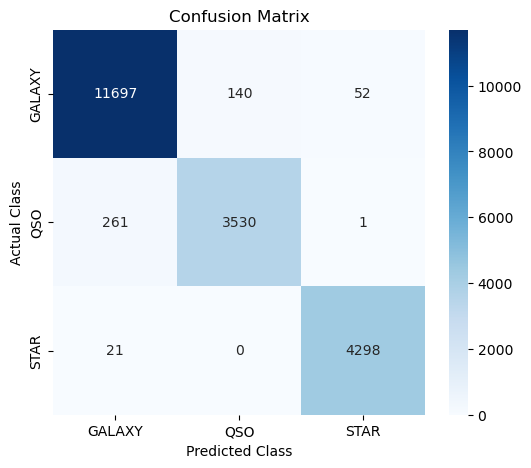

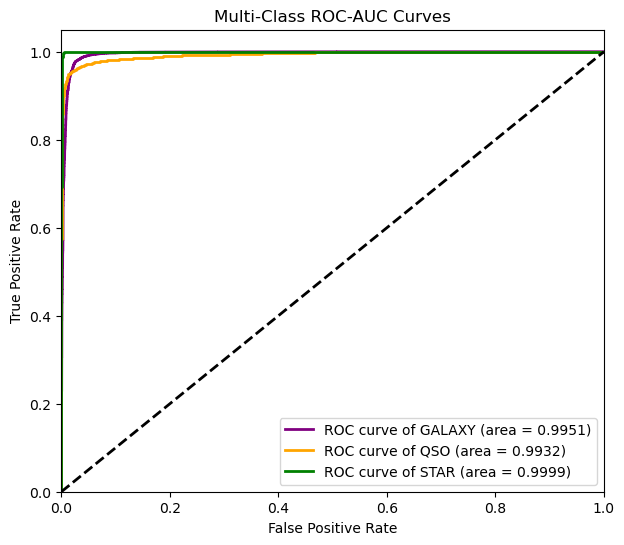

/var/folders/4t/rm334mbx28jgr4xw4k0t_ssc0000gn/T/ipykernel_23507/898694131.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette='viridis')


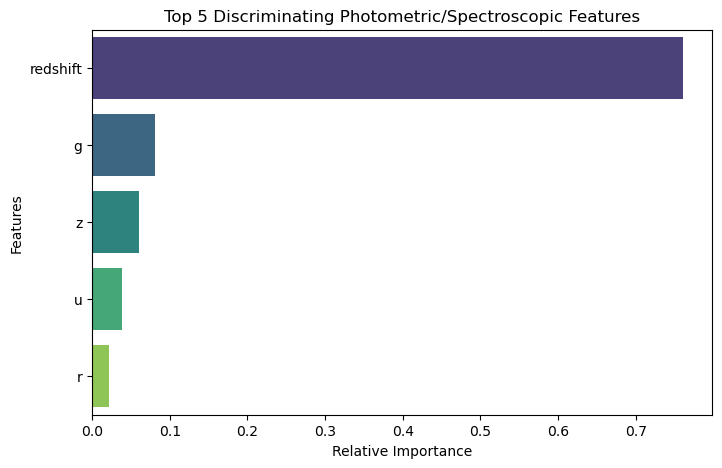

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# 1. EVALUATION METRICS
# ==========================================
# Predict on the test set
y_pred = model.predict(X_test_scaled)
y_score = model.predict_proba(X_test_scaled)

# Calculate verification scores
accuracy = accuracy_score(y_test, y_pred)
print("=== VERIFICATION METRICS ===")
print(f"Overall Accuracy: {accuracy:.4f} (Target: >= 0.93)")
print("\nPer-Class Precision, Recall, and F1-Score:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ==========================================
# 2. CONFUSION MATRIX PLOT
# ==========================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# ==========================================
# 3. MULTI-CLASS ROC-AUC CURVES
# ==========================================
# Binarize the output labels for ROC calculation
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

plt.figure(figsize=(7, 6))
colors = ['purple', 'orange', 'green']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {label_encoder.classes_[i]} (area = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC-AUC Curves')
plt.legend(loc="lower right")
plt.show()

# ==========================================
# 4. FEATURE IMPORTANCE BAR CHART (TOP 5)
# ==========================================
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Take the top 5 discriminating features
top_k = 5
top_indices = indices[:top_k]
top_features = [X.columns[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(8, 5))
sns.barplot(x=top_importances, y=top_features, palette='viridis')
plt.title('Top 5 Discriminating Photometric/Spectroscopic Features')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.show()